# Part 3: Low-Rank Adaptation (LoRA)
## Parameter-Efficient Fine-Tuning for NanoGPT

This notebook implements LoRA (Low-Rank Adaptation) from scratch and compares it against full fine-tuning on the speaker identification and verse/prose classification tasks.

## 1. Setup and Imports

In [1]:
import os
import re
import copy
import random
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import pickle
import sys
import time

sys.path.append("nanoGPT")
from model import GPTConfig, GPT

# Setup
BASE = "data/shakespeare_char"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Hyperparameters
block_size = 256
batch_size = 64
eval_iters = 100

Using device: cuda


## 2. Load Pretrained Model and Data

In [2]:
# Load pretrained checkpoint from Part 1
ckpt = torch.load("out-shakespeare-S-split100\\ckpt.pt", map_location=DEVICE)
model = GPT(GPTConfig(**ckpt["model_args"]))
state_dict = ckpt["model"]
state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

print(f"Pretrained model loaded. Total parameters: {sum(p.numel() for p in model.parameters())}")

number of parameters: 0.80M
Pretrained model loaded. Total parameters: 828672


## 3. Load Vocabulary and Data

In [3]:
# Load vocabulary
meta_path = os.path.join(BASE, "meta.pkl")
with open(meta_path, "rb") as f:
    meta = pickle.load(f)

stoi = meta["stoi"]
itos = meta["itos"]

# Add special tokens
special_text = "[SPEAKER][ANSWER][END][CLASSIFY]"
for ch in special_text:
    if ch not in stoi:
        stoi[ch] = len(stoi)
        itos[len(itos)] = ch

vocab_size = len(stoi)

# Extend embedding to fit new tokens
old_vocab_size = model.config.vocab_size
new_vocab_size = len(stoi)

if new_vocab_size > old_vocab_size:
    print(f"Extending vocabulary from {old_vocab_size} to {new_vocab_size}")
    
    # Get old embedding data on the correct device
    old_emb_data = model.transformer.wte.weight.data.clone()
    old_lm_data = model.lm_head.weight.data.clone()
    
    # Create new embeddings DIRECTLY on target device
    new_emb = torch.nn.Embedding(new_vocab_size, model.config.n_embd, device=DEVICE)
    new_emb.weight.data[:old_vocab_size] = old_emb_data
    
    new_lm = torch.nn.Linear(model.config.n_embd, new_vocab_size, bias=False, device=DEVICE)
    new_lm.weight.data[:old_vocab_size] = old_lm_data
    
    # Replace in model
    model.transformer.wte = new_emb
    model.lm_head = new_lm
    
    model.config.vocab_size = new_vocab_size

# Final safety: move entire model to device and verify
model = model.to(DEVICE)
for name, param in model.named_parameters():
    if param.device != torch.device(DEVICE):
        param.data = param.data.to(DEVICE)

# Define encode/decode functions
def encode(text):
    return [stoi[c] for c in text]

def decode(indices):
    return "".join([itos[i] for i in indices])


Extending vocabulary from 65 to 67


## 4. Load Training Data

In [ ]:
# Load validation data for loss estimation
val_data = np.memmap(
    f"{BASE}/val.bin",
    dtype=np.uint16,
    mode="r"
).astype(np.int64)

def load_classify_dataset(filepath):
    """Load classification dataset where samples span multiple lines.
    Each sample starts with [CLASSIFY] and ends with [END].
    Returns list of full sample strings."""
    with open(filepath, "r") as f:
        content = f.read()
    
    # Split by [CLASSIFY] to get individual samples
    samples_raw = content.split("[CLASSIFY]")
    
    # Filter out empty strings and reconstruct samples with [CLASSIFY] prefix
    samples = []
    for sample_text in samples_raw[1:]:  # Skip first empty element
        # Find the [END] marker
        if "[END]" in sample_text:
            sample = "[CLASSIFY]" + sample_text.split("[END]")[0] + "[END]"
            samples.append(sample)
    
    return samples

# Load task data
taskA_train = None
taskA_test = None
taskB_train = load_classify_dataset(f"{BASE}/sft_classify_train.txt")
taskB_test = load_classify_dataset(f"{BASE}/sft_classify_test.txt")

# Load speaker identification data
with open(f"{BASE}/sft_speaker_train.txt", "r") as f:
    speaker_train_content = f.read()
    if "[SPEAKER]" in speaker_train_content:
        # Multi-line format like classify
        samples_raw = speaker_train_content.split("[SPEAKER]")
        taskA_train = []
        for sample_text in samples_raw[1:]:
            if "[END]" in sample_text:
                sample = "[SPEAKER]" + sample_text.split("[END]")[0] + "[END]"
                taskA_train.append(sample)
    else:
        # Line-by-line format
        taskA_train = [line.strip() for line in speaker_train_content.strip().split("\n")]

with open(f"{BASE}/sft_speaker_test.txt", "r") as f:
    speaker_test_content = f.read()
    if "[SPEAKER]" in speaker_test_content:
        samples_raw = speaker_test_content.split("[SPEAKER]")
        taskA_test = []
        for sample_text in samples_raw[1:]:
            if "[END]" in sample_text:
                sample = "[SPEAKER]" + sample_text.split("[END]")[0] + "[END]"
                taskA_test.append(sample)
    else:
        taskA_test = [line.strip() for line in speaker_test_content.strip().split("\n")]

print(f"Task A: {len(taskA_train)} train, {len(taskA_test)} test")
print(f"Task B: {len(taskB_train)} train, {len(taskB_test)} test")

Task A: 500 train, 100 test
Task B: 500 train, 100 test


## 5. Utility Functions

In [ ]:
def get_batch(data):
    """Sample a batch from training data"""
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.tensor(data[i:i+block_size]) for i in ix])
    y = torch.stack([torch.tensor(data[i+1:i+block_size+1]) for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

def estimate_val_loss(model):
    """Compute validation loss"""
    model.eval()
    losses = []
    for _ in range(eval_iters):
        xb, yb = get_batch(val_data)
        with torch.no_grad():
            _, loss = model(xb, yb)
        losses.append(loss.item())
    return sum(losses) / len(losses)

def build_array(text_list):
    """Convert text list to numpy array of token IDs"""
    text = "\n".join(text_list)
    return np.array(encode(text), dtype=np.int64)

def extract_answer(text):
    """Extract answer from model output"""
    if "[ANSWER]" in text:
        return text.split("[ANSWER]")[1].split("[END]")[0].strip()
    return ""

print("Utility functions loaded.")

Utility functions loaded.


## 6. LoRA Implementation

In [ ]:
class LoRALinear(nn.Module):
    """LoRA-augmented linear layer"""
    def __init__(self, original_linear, rank=4, lora_alpha=1.0, target_device='cuda'):
        super().__init__()
        self.original = original_linear
        self.target_device = target_device
        
        # Move original layer to target device if needed
        self.original = self.original.to(target_device)
        
        # Freeze original weights
        self.original.weight.requires_grad = False
        if self.original.bias is not None:
            self.original.bias.requires_grad = False
        
        # Get dimensions from original layer
        d_out, d_in = original_linear.weight.shape
        
        # Explicitly create LoRA matrices on target device
        self.lora_A = nn.Parameter(torch.randn(rank, d_in, device=target_device) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(d_out, rank, device=target_device))
        
        # Ensure trainable
        self.lora_A.requires_grad = True
        self.lora_B.requires_grad = True
        
        self.rank = rank
        self.lora_alpha = lora_alpha
        self.scaling = self.lora_alpha / rank
    
    def forward(self, x):
        # Ensure all components are on correct device
        x = x.to(self.target_device)
        
        # Move original layer to device (in case of device changes)
        for param in self.original.parameters():
            param.data = param.data.to(self.target_device)
        
        # Original forward pass
        out = self.original(x)
        
        # Add LoRA update: (x @ A^T) @ B^T
        lora_update = (x @ self.lora_A.T) @ self.lora_B.T
        return out + self.scaling * lora_update
    
    def get_trainable_params(self):
        """Return number of trainable parameters"""
        return self.lora_A.numel() + self.lora_B.numel()


def inject_lora(model, rank=4, target_modules=['c_attn'], target_device='cuda'):
    """Inject LoRA layers into the model with proper device handling"""
    # Step 1: Get original device and ensure model is on it
    original_device = next(model.parameters()).device
    target_device = str(original_device)  # Use actual device
    
    # Move to target device BEFORE deepcopy
    model = model.to(target_device)
    
    # Deepcopy
    lora_model = copy.deepcopy(model)
    
    # Move to target device AFTER deepcopy 
    lora_model = lora_model.to(target_device)
    
    # Freeze all parameters
    for param in lora_model.parameters():
        param.requires_grad = False
    
    # Replace target modules with LoRA versions
    total_lora_params = 0
    found_modules = []
    
    for name, module in lora_model.named_modules():
        if isinstance(module, nn.Linear) and any(target in name for target in target_modules):
            # Get parent and attribute name
            parent_name = ".".join(name.split(".")[:-1])
            attr_name = name.split(".")[-1]
            
            # Get parent module
            parent = lora_model
            for part in parent_name.split("."):
                if part:
                    parent = getattr(parent, part)
            
            # Replace with LoRA layer (explicitly pass target_device)
            lora_layer = LoRALinear(module, rank=rank, target_device=target_device)
            setattr(parent, attr_name, lora_layer)
            total_lora_params += lora_layer.get_trainable_params()
            found_modules.append(name)
    
    # Final device verification - move entire model one more time
    lora_model = lora_model.to(target_device)
    
    # Verify all parameters are on target device
    device_mismatches = []
    for name, param in lora_model.named_parameters():
        if param.device != torch.device(target_device):
            device_mismatches.append((name, param.device))
    
    if device_mismatches:
        print(f"  WARNING: Device mismatches detected:")
        for name, device in device_mismatches:
            print(f"    - {name}: {device} (expected {target_device})")
        # Force move all parameters
        for param in lora_model.parameters():
            param.data = param.data.to(target_device)
    
    # Debug: Print what was injected
    print(f"  LoRA injection: Found and wrapped {len(found_modules)} modules on {target_device}")
    for mod in found_modules:
        print(f"    - {mod}")
    
    return lora_model, total_lora_params


def count_trainable_params(model):
    """Count trainable parameters in model"""
    count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return count

print("LoRA implementation loaded.")


LoRA implementation loaded.


## 7. Training and Evaluation Functions

In [ ]:
def fine_tune(base_model, train_data, title, lr=5e-5, max_iters=2000, save_plot=False):
    """Fine-tune model on training data"""
    model = copy.deepcopy(base_model)
    model = model.to(DEVICE)  # Explicit device move
    
    # deepcopy can scatter parameters. Ensure embedding is on device
    if hasattr(model.transformer, 'wte'):
        model.transformer.wte = model.transformer.wte.to(DEVICE)
    if hasattr(model, 'lm_head'):
        model.lm_head = model.lm_head.to(DEVICE)
    
    model.train()
    
    # Verify device placement before training
    param_devices = set()
    for p in model.parameters():
        param_devices.add(str(p.device))
    if len(param_devices) > 1:
        print(f"  WARNING: Multiple devices detected during training: {param_devices}")
        print(f"  Moving all parameters to {DEVICE}")
        for param in model.parameters():
            param.data = param.data.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []

    for step in range(max_iters):
        xb, yb = get_batch(train_data)
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)  # Explicit device move
        logits, loss = model(xb, yb)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())

        if step % 200 == 0:
            print(f"{title} | step {step} | loss {loss.item():.4f}")

    if save_plot:
        plt.figure()
        plt.plot(losses)
        plt.title(title)
        plt.xlabel("Step")
        plt.ylabel("Loss")
        os.makedirs("train_plots", exist_ok=True)
        plt.savefig(f"train_plots/{title}_loss.png")
        plt.close()

    return model, losses


def compute_taskA_accuracy(model):
    """Compute speaker identification accuracy"""
    model.eval()
    model = model.to(DEVICE)  # Explicit device move
    
    # Safety: ensure embeddings are on device
    if hasattr(model.transformer, 'wte'):
        model.transformer.wte = model.transformer.wte.to(DEVICE)
    if hasattr(model, 'lm_head'):
        model.lm_head = model.lm_head.to(DEVICE)
    
    correct = 0
    longest_label = 0
    
    # First pass: find longest label
    for ex in taskA_test:
        label = extract_answer(ex)
        if len(label) > longest_label:
            longest_label = len(label)

    # Second pass: evaluate
    for ex in taskA_test:
        line = ex.split("[SPEAKER]")[1].split("[ANSWER]")[0].strip()
        label = extract_answer(ex)
        prompt = f"[SPEAKER] {line} [ANSWER] "
        idx = torch.tensor(encode(prompt)).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            out = model.generate(idx, max_new_tokens=longest_label + len(" [END]"))
        pred_text = decode(out[0].tolist())
        pred = extract_answer(pred_text)
        
        if pred == label:
            correct += 1

    accuracy = correct / len(taskA_test)
    return accuracy


def compute_taskB_accuracy(model):

    model.eval()
    correct = 0

    for ex in taskB_test:
        label = extract_answer(ex)
        prompt = ex.split("[ANSWER]")[0] + "[ANSWER] "
        idx = torch.tensor(encode(prompt)).unsqueeze(0).to(DEVICE)
        # VERSE and PROSE have the same length
        out = model.generate(idx, max_new_tokens=len("VERSE [END]"))
        pred_text = decode(out[0].tolist())
        pred = extract_answer(pred_text)

        print(f"pred={pred:20s} | label={label:20s} | pred_text={pred_text}")
        if pred == label:
            correct += 1

    return correct / len(taskB_test)

print("Training and evaluation functions loaded.")


Training and evaluation functions loaded.


## 8. Prepare Training Data

In [9]:
# Build training arrays
A_train_data = build_array(taskA_train)
B_train_data = build_array(taskB_train)

print(f"Task A training data: {len(A_train_data)} tokens")
print(f"Task B training data: {len(B_train_data)} tokens")

Task A training data: 37347 tokens
Task B training data: 112716 tokens


## Pre-Experiments
To get an intuition of learning rate and max iterations, lets run LoRA with some different hyperparameter values and ranks:

In [28]:
print("\n" + "=" * 80)
print("EXPERIMENT 5: LoRA Rank Ablation on Task A")
print("=" * 80)

rank_results = []
lrs = [5e-3, 1e-2, 5e-2, 1e-1]
max_iters = [2500, 5000, 7500, 10000]

ranks = [1, 2, 4, 8, 16]
for lr in lrs:
    for max_iter in max_iters:
        for rank in ranks:
            print(f"\n--- Rank {rank} ---")
            lora_model = copy.deepcopy(model)
            lora_model = lora_model.to(DEVICE)
            lora_model, _ = inject_lora(lora_model, rank=rank, target_device=DEVICE)
            trainable_params = count_trainable_params(lora_model)
            print(f"Trainable parameters: {trainable_params}")

            lora_model, _ = fine_tune(lora_model, A_train_data, f"LoRA_Task_A_Rank{rank}", lr=lr, max_iters=max_iter)
            lora_model = lora_model.to(DEVICE)  # Ensure device after fine_tune
            acc = compute_taskA_accuracy(lora_model)
            val_loss = estimate_val_loss(lora_model)

            rank_results.append({
                'rank': rank,
                'trainable_params': trainable_params,
                'accuracy': acc,
                'val_loss': val_loss,
                'max_iter': max_iter,
                'lr': lr
            })

            print(f"Rank {rank} - Accuracy: {acc:.4f}, Val Loss: {val_loss:.4f}")

# Create rank ablation dataframe
rank_df = pd.DataFrame(rank_results)
print("\n" + "=" * 80)
print("RANK ABLATION RESULTS")
print("=" * 80)
print(rank_df.to_string(index=False))



EXPERIMENT 5: LoRA Rank Ablation on Task A

--- Rank 1 ---
  LoRA injection: Found and wrapped 4 modules on cuda:0
    - transformer.h.0.attn.c_attn
    - transformer.h.1.attn.c_attn
    - transformer.h.2.attn.c_attn
    - transformer.h.3.attn.c_attn
Trainable parameters: 2048
LoRA_Task_A_Rank1 | step 0 | loss 3.5068
LoRA_Task_A_Rank1 | step 200 | loss 1.6989
LoRA_Task_A_Rank1 | step 400 | loss 1.6087
LoRA_Task_A_Rank1 | step 600 | loss 1.6028
LoRA_Task_A_Rank1 | step 800 | loss 1.5715
LoRA_Task_A_Rank1 | step 1000 | loss 1.5576
LoRA_Task_A_Rank1 | step 1200 | loss 1.5392
LoRA_Task_A_Rank1 | step 1400 | loss 1.5547
LoRA_Task_A_Rank1 | step 1600 | loss 1.5521
LoRA_Task_A_Rank1 | step 1800 | loss 1.5347
LoRA_Task_A_Rank1 | step 2000 | loss 1.5318
LoRA_Task_A_Rank1 | step 2200 | loss 1.5359
LoRA_Task_A_Rank1 | step 2400 | loss 1.5494
Rank 1 - Accuracy: 0.0100, Val Loss: 1.6709

--- Rank 2 ---
  LoRA injection: Found and wrapped 4 modules on cuda:0
    - transformer.h.0.attn.c_attn
    - 

It seems like we neither want too much nor too little lr and max_iters. 5000 iterations and a learning rate of 0.005 seems to be appropriate for most ranks.
Lets test these parameters for task B:

In [ ]:
print("\n" + "=" * 80)
print("EXPERIMENT 5: LoRA Rank Ablation on Task A")
print("=" * 80)

rank_resultsB = []
lrsB = [5e-3]
max_itersB = [5000]

ranksB = [1, 2, 4, 8, 16]
for lr in lrsB:
    for max_iter in max_itersB:
        for rank in ranksB:
            print(f"\n--- Rank {rank} ---")
            lora_modelB = copy.deepcopy(model)
            lora_modelB = lora_modelB.to(DEVICE)
            lora_modelB, _ = inject_lora(lora_modelB, rank=rank, target_device=DEVICE)
            trainable_paramsB = count_trainable_params(lora_modelB)
            print(f"Trainable parameters: {trainable_paramsB}")

            lora_modelB, _ = fine_tune(lora_modelB, B_train_data, f"LoRA_Task_B_Rank{rank}", lr=lr, max_iters=max_iter)
            lora_modelB = lora_modelB.to(DEVICE)  # Ensure device after fine_tune
            accB = compute_taskB_accuracy(lora_modelB)
            val_lossB = estimate_val_loss(lora_modelB)

            rank_resultsB.append({
                'rank': rank,
                'trainable_params': trainable_paramsB,
                'accuracy': accB,
                'val_loss': val_lossB,
                'max_iter': max_iter,
                'lr': lr
            })

            print(f"Rank {rank} - Accuracy: {accB:.4f}, Val Loss: {val_lossB:.4f}")

# Create rank ablation dataframe
rank_dfB = pd.DataFrame(rank_resultsB)
print("\n" + "=" * 80)
print("RANK ABLATION RESULTS")
print("=" * 80)
print(rank_dfB.to_string(index=False))



EXPERIMENT 5: LoRA Rank Ablation on Task A

--- Rank 1 ---
  LoRA injection: Found and wrapped 4 modules on cuda:0
    - transformer.h.0.attn.c_attn
    - transformer.h.1.attn.c_attn
    - transformer.h.2.attn.c_attn
    - transformer.h.3.attn.c_attn
Trainable parameters: 2048
LoRA_Task_B_Rank1 | step 0 | loss 2.2784
LoRA_Task_B_Rank1 | step 200 | loss 1.6878
LoRA_Task_B_Rank1 | step 400 | loss 1.6132
LoRA_Task_B_Rank1 | step 600 | loss 1.6287
LoRA_Task_B_Rank1 | step 800 | loss 1.6160
LoRA_Task_B_Rank1 | step 1000 | loss 1.6076
LoRA_Task_B_Rank1 | step 1200 | loss 1.5904
LoRA_Task_B_Rank1 | step 1400 | loss 1.5841
LoRA_Task_B_Rank1 | step 1600 | loss 1.5949
LoRA_Task_B_Rank1 | step 1800 | loss 1.5544
LoRA_Task_B_Rank1 | step 2000 | loss 1.6067
LoRA_Task_B_Rank1 | step 2200 | loss 1.5809
LoRA_Task_B_Rank1 | step 2400 | loss 1.5999
LoRA_Task_B_Rank1 | step 2600 | loss 1.5632
LoRA_Task_B_Rank1 | step 2800 | loss 1.5930
LoRA_Task_B_Rank1 | step 3000 | loss 1.5913
LoRA_Task_B_Rank1 | step

These hyperparameters seem fine for task B too.

## Experiment 4: LoRA Single-Task SFT

In [ ]:
print("=" * 80)
print("EXPERIMENT 4: LoRA Single-Task SFT (Rank 4)")
print("=" * 80)

experiment4_results = {}

# LoRA Task A
print("--- LoRA Task A ---")
lora_model_A = copy.deepcopy(model)
lora_model_A = lora_model_A.to(DEVICE)
lora_model_A, lora_params_A = inject_lora(lora_model_A, rank=4, target_device=DEVICE)
print(f"Trainable parameters: {count_trainable_params(lora_model_A)}")

# use best params from rank ablation for rank 4
lora_model_A, _ = fine_tune(lora_model_A, A_train_data, "LoRA_Task_A", lr=5e-3, max_iters=5000)
lora_model_A = lora_model_A.to(DEVICE)  # Ensure device after fine_tune
acc_lora_A = compute_taskA_accuracy(lora_model_A)
val_lora_A = estimate_val_loss(lora_model_A)
torch.save(lora_model_A, "lora_model_A_rank4.pt")

experiment4_results['lora_A_rank4'] = {
    'rank': 4,
    'trainable_params': count_trainable_params(lora_model_A),
    'accuracy': acc_lora_A,
    'val_loss': val_lora_A
}

print(f"LoRA Task A - Accuracy: {acc_lora_A:.4f}, Val Loss: {val_lora_A:.4f}")

# LoRA Task B
print("\n--- LoRA Task B ---")
lora_model_B = copy.deepcopy(model)
lora_model_B = lora_model_B.to(DEVICE)
lora_model_B, lora_params_B = inject_lora(lora_model_B, rank=4, target_device=DEVICE)
print(f"Trainable parameters: {count_trainable_params(lora_model_B)}")

# use best params from rank ablation for rank 4
lora_model_B, _ = fine_tune(lora_model_B, B_train_data, "LoRA_Task_B", lr=5e-3, max_iters=5000, save_plot=True)
lora_model_B = lora_model_B.to(DEVICE)  # Ensure device after fine_tune
acc_lora_B = compute_taskB_accuracy(lora_model_B)
val_lora_B = estimate_val_loss(lora_model_B)
torch.save(lora_model_B, "lora_model_B_rank4.pt")

experiment4_results['lora_B_rank4'] = {
    'rank': 4,
    'trainable_params': count_trainable_params(lora_model_B),
    'accuracy': acc_lora_B,
    'val_loss': val_lora_B
}

print(f"LoRA Task B - Accuracy: {acc_lora_B:.4f}, Val Loss: {val_lora_B:.4f}")


EXPERIMENT 4: LoRA Single-Task SFT (Rank 4)

Pre-experiment device check...
✓ Model ready on cuda

--- LoRA Task A ---
  LoRA injection: Found and wrapped 4 modules on cuda:0
    - transformer.h.0.attn.c_attn
    - transformer.h.1.attn.c_attn
    - transformer.h.2.attn.c_attn
    - transformer.h.3.attn.c_attn
Trainable parameters: 8192
LoRA_Task_A | step 0 | loss 3.4983
LoRA_Task_A | step 200 | loss 1.3609
LoRA_Task_A | step 400 | loss 1.2181
LoRA_Task_A | step 600 | loss 1.1575
LoRA_Task_A | step 800 | loss 1.1314
LoRA_Task_A | step 1000 | loss 1.1343
LoRA_Task_A | step 1200 | loss 1.1182
LoRA_Task_A | step 1400 | loss 1.1147
LoRA_Task_A | step 1600 | loss 1.1095
LoRA_Task_A | step 1800 | loss 1.1066
LoRA_Task_A | step 2000 | loss 1.0836
LoRA_Task_A | step 2200 | loss 1.0991
LoRA_Task_A | step 2400 | loss 1.0817
LoRA_Task_A | step 2600 | loss 1.1016
LoRA_Task_A | step 2800 | loss 1.0883
LoRA_Task_A | step 3000 | loss 1.1142
LoRA_Task_A | step 3200 | loss 1.0560
LoRA_Task_A | step 3400

In [31]:
# create dataframe for experiment 4
exp4_df = pd.DataFrame.from_dict(experiment4_results, orient='index')
print("\n" + "=" * 80)
print("EXPERIMENT 4 RESULTS")
print("=" * 80)
print(exp4_df.to_string())


EXPERIMENT 4 RESULTS
              rank  trainable_params  accuracy  val_loss
lora_A_rank4     4              8192  0.100000  1.812256
lora_B_rank4     4              8192  0.118966  1.627011


## Experiment 5: LoRA rank ablation

In [17]:
ranks = [1, 2, 4, 8, 16]
exp5_results = []

for rank in ranks:
    print(f"\n--- Rank {rank} ---")
    
    lora_model = copy.deepcopy(model)
    lora_model = lora_model.to(DEVICE)
    lora_model, _ = inject_lora(lora_model, rank=rank, target_device=DEVICE)
    trainable_params = count_trainable_params(lora_model)
    print(f"Trainable parameters: {trainable_params}")

    rank_start_time = time.time()
    lora_model, _ = fine_tune(lora_model, A_train_data, f"LoRA_Task_A_Rank{rank}", lr=5e-3, max_iters=5000)
    rank_time = time.time() - rank_start_time
    lora_model = lora_model.to(DEVICE)  # Ensure device after fine_tune
    acc = compute_taskA_accuracy(lora_model)
    val_loss = estimate_val_loss(lora_model)
    

    exp5_results.append({
        'rank': rank,
        'trainable_params': trainable_params,
        'accuracy': acc,
        'val_loss': val_loss,
        'time_seconds': rank_time
    })

    print(f"Rank {rank} - Accuracy: {acc:.4f}, Val Loss: {val_loss:.4f}, Time: {rank_time:.2f}s")

# compare to full fine tune model
print("\n" + "=" * 80)
print("EXPERIMENT 1: Full Fine-Tuning")
print("=" * 80)
full_fine_tune_results = {}
# Full fine-tune Task A
print("--- Full Fine-Tune Task A ---")
full_model_A = copy.deepcopy(model)
full_model_A = full_model_A.to(DEVICE)
trainable_params = count_trainable_params(full_model_A)
print(f"Trainable parameters: {trainable_params}")
# use best params from task 2
full_start_time = time.time()
full_model_A, _ = fine_tune(full_model_A, A_train_data, "Full_FineTune_Task_A", lr=5e-4, max_iters=3000)
full_time = time.time() - full_start_time
full_model_A = full_model_A.to(DEVICE)  # Ensure device after fine_tune
acc_full_A = compute_taskA_accuracy(full_model_A)
val_full_A = estimate_val_loss(full_model_A)
exp5_results.append({
    'rank': 'Full FT',
    'trainable_params': trainable_params,
    'accuracy': acc_full_A,
    'val_loss': val_full_A,
    'time_seconds': full_time
})
print(f"Full Fine-Tune Task A - Accuracy: {acc_full_A:.4f}, Val Loss: {val_full_A:.4f}")


exp5_df = pd.DataFrame(exp5_results)

# Print results dataframe
print("\n" + "=" * 80)
print("EXPERIMENT 5 RESULTS WITH TIMING")
print("=" * 80)
print(exp5_df.to_string(index=False))



--- Rank 1 ---
  LoRA injection: Found and wrapped 4 modules on cuda:0
    - transformer.h.0.attn.c_attn
    - transformer.h.1.attn.c_attn
    - transformer.h.2.attn.c_attn
    - transformer.h.3.attn.c_attn
Trainable parameters: 2048
LoRA_Task_A_Rank1 | step 0 | loss 3.4363
LoRA_Task_A_Rank1 | step 200 | loss 1.6948
LoRA_Task_A_Rank1 | step 400 | loss 1.6230
LoRA_Task_A_Rank1 | step 600 | loss 1.5694
LoRA_Task_A_Rank1 | step 800 | loss 1.5224
LoRA_Task_A_Rank1 | step 1000 | loss 1.5376
LoRA_Task_A_Rank1 | step 1200 | loss 1.5316
LoRA_Task_A_Rank1 | step 1400 | loss 1.5134
LoRA_Task_A_Rank1 | step 1600 | loss 1.5160
LoRA_Task_A_Rank1 | step 1800 | loss 1.5390
LoRA_Task_A_Rank1 | step 2000 | loss 1.5255
LoRA_Task_A_Rank1 | step 2200 | loss 1.5192
LoRA_Task_A_Rank1 | step 2400 | loss 1.5400
LoRA_Task_A_Rank1 | step 2600 | loss 1.5378
LoRA_Task_A_Rank1 | step 2800 | loss 1.5110
LoRA_Task_A_Rank1 | step 3000 | loss 1.5027
LoRA_Task_A_Rank1 | step 3200 | loss 1.5110
LoRA_Task_A_Rank1 | step

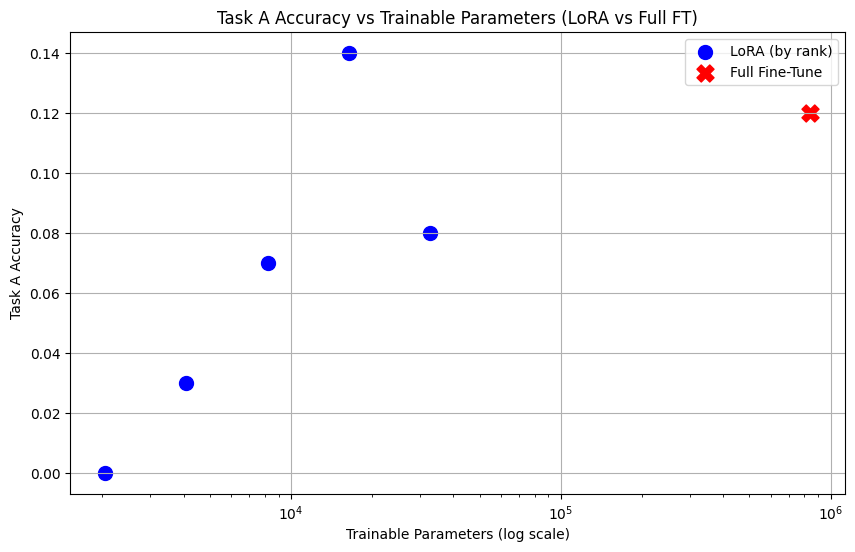

In [20]:
# Plot accuracy vs trainable parameters for LoRA ranks and Full Fine-Tune
plt.figure(figsize=(10, 6))

lora_res = [res for res in exp5_results if isinstance(res['rank'], int)]
ft_res = [res for res in exp5_results if res['rank'] == 'Full FT']

# LoRA points (one per rank)
lora_params = [res['trainable_params'] for res in lora_res]
lora_acc = [res['accuracy'] for res in lora_res]
plt.scatter(lora_params, lora_acc, label='LoRA (by rank)', s=100, color='blue')

# Full fine-tuning point(s)
ft_params = [res['trainable_params'] for res in ft_res]
ft_acc = [res['accuracy'] for res in ft_res]
plt.scatter(ft_params, ft_acc, label='Full Fine-Tune', color='red', s=150, marker='X')

plt.xscale('log')
plt.xlabel('Trainable Parameters (log scale)')
plt.ylabel('Task A Accuracy')
plt.title('Task A Accuracy vs Trainable Parameters (LoRA vs Full FT)')
plt.legend()
plt.grid(True)
plt.savefig("train_plots/experiment5_accuracy_vs_params.png")
plt.show()

## Experiment 6: LoRA vs. full fine-tuning

In [13]:
print("\n" + "=" * 80)
print("EXPERIMENT 6: LoRA vs. Full Fine-Tuning on Task A")
print("=" * 80)

comparison_results = []

# Full Fine-Tuning
print("\n--- Full Fine-Tuning ---")
full_ft_model = copy.deepcopy(model)            
full_ft_model = full_ft_model.to(DEVICE)
ft_trainable_before = count_trainable_params(full_ft_model)
# Unfreeze all parameters for full fine-tuning
for param in full_ft_model.parameters():
    param.requires_grad = True

start_time = time.time()

# use best parameters from task 2
full_ft_model, _ = fine_tune(full_ft_model, A_train_data, "Full_FT_Task_A", lr=1e-4, max_iters=3000)
full_ft_model = full_ft_model.to(DEVICE)  # Ensure device after fine_tune
ft_time = time.time() - start_time

acc_ft = compute_taskA_accuracy(full_ft_model)
val_ft = estimate_val_loss(full_ft_model)
ft_trainable = count_trainable_params(full_ft_model)

comparison_results.append({
    'Method': 'Full FT',
    'Rank': '-',
    'Trainable Params': ft_trainable,
    'Task A Accuracy': acc_ft,
    'Shakespeare Val Loss': val_ft,
    'Time (sec)': ft_time
})

print(f"Full FT - Accuracy: {acc_ft:.4f}, Val Loss: {val_ft:.4f}, Time: {ft_time:.2f}s")

# LoRA with different ranks
print(f"\n--- LoRA Rank 4 ---")
lora_model = copy.deepcopy(model)
lora_model = lora_model.to(DEVICE)
lora_model, _ = inject_lora(lora_model, rank=4, target_device=DEVICE)
trainable_params = count_trainable_params(lora_model)

start_time = time.time()

# use best parameters from rank ablation test
lora_model, _ = fine_tune(lora_model, A_train_data, f"LoRA_Task_A_Rank4_Comp", lr=5e-3, max_iters=5000)
lora_model = lora_model.to(DEVICE)  # Ensure device after fine_tune
lora_time = time.time() - start_time

acc_lora = compute_taskA_accuracy(lora_model)
val_lora = estimate_val_loss(lora_model)

comparison_results.append({
    'Method': 'LoRA Task A',
    'Rank': 4,
    'Trainable Params': trainable_params,
    'Task A Accuracy': acc_lora,
    'Shakespeare Val Loss': val_lora,
    'Time (sec)': lora_time
})

print(f"LoRA Rank 4 - Accuracy: {acc_lora:.4f}, Val Loss: {val_lora:.4f}, Time: {lora_time:.2f}s")


start_time = time.time()
print("Finetuning Multi Task A+B")
# randomize training data for both 
combined = taskA_train + taskB_train
random.shuffle(combined)
mixed = build_array(combined)
model_multi, _ = fine_tune(model, mixed, f"Multi_Task{lr}_{max_iter}", lr=5e-3, max_iters=5000)
multi_time = time.time() - start_time

acc_multi = compute_taskA_accuracy(model_multi)
val_multi = estimate_val_loss(model_multi)

comparison_results.append({
    'Method': 'LoRA Multi',
    'Rank': 4,
    'Trainable Params': trainable_params,
    'Task A Accuracy': acc_multi,
    'Shakespeare Val Loss': val_multi,
    'Time (sec)': multi_time
})

print(f"Multi LoRA Rank 4 - Accuracy: {acc_multi:.4f}, Val Loss: {val_multi:.4f}, Time: {multi_time:.2f}s")

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_results)
print("\n" + "=" * 80)
print("COMPARISON: Full Fine-Tuning vs. LoRA")
print("=" * 80)
print(comparison_df.to_string(index=False))


EXPERIMENT 6: LoRA vs. Full Fine-Tuning on Task A

--- Full Fine-Tuning ---
Full_FT_Task_A | step 0 | loss 3.4493
Full_FT_Task_A | step 200 | loss 0.9271
Full_FT_Task_A | step 400 | loss 0.8284
Full_FT_Task_A | step 600 | loss 0.7833
Full_FT_Task_A | step 800 | loss 0.7562
Full_FT_Task_A | step 1000 | loss 0.7206
Full_FT_Task_A | step 1200 | loss 0.6781
Full_FT_Task_A | step 1400 | loss 0.6350
Full_FT_Task_A | step 1600 | loss 0.6217
Full_FT_Task_A | step 1800 | loss 0.5883
Full_FT_Task_A | step 2000 | loss 0.5813
Full_FT_Task_A | step 2200 | loss 0.5400
Full_FT_Task_A | step 2400 | loss 0.5102
Full_FT_Task_A | step 2600 | loss 0.4987
Full_FT_Task_A | step 2800 | loss 0.4675
Full FT - Accuracy: 0.1200, Val Loss: 3.4045, Time: 106.56s

--- LoRA Rank 4 ---
  LoRA injection: Found and wrapped 4 modules on cuda:0
    - transformer.h.0.attn.c_attn
    - transformer.h.1.attn.c_attn
    - transformer.h.2.attn.c_attn
    - transformer.h.3.attn.c_attn
LoRA_Task_A_Rank4_Comp | step 0 | loss 3.4

## Experiment 6 Results Summary

| Method | Rank | Trainable Params | Task A Accuracy | Shakespeare Val Loss | Time (sec) |
|--------|------|------------------|-----------------|----------------------|------------|
| Full FT | - | 837,504 | 0.12 | 3.40 | 106.56 |
| LoRA Task A | 4 | 8,192 | 0.03 | 1.99 | 171.33 |
| LoRA Multi | 4 | 8,192 | 0.06 | 2.16 | 177.61 |

- Full Fine-Tuning uses way more trainable parameters than LoRA
- LoRA Task A has lower validation loss on Shakespeare but lower task accuracy


## Catastrophic Forgetting Comparison: Samples

In [24]:
def generate_unconditional(model):
    model = model.to(DEVICE)
    idx = torch.zeros((1,1), dtype=torch.long).to(DEVICE)
    out = model.generate(idx, max_new_tokens=500)
    return decode(out[0].tolist())
print(generate_unconditional(lora_model))
print(generate_unconditional(full_ft_model))


NSWELER] ROMEO [END]
[SPEAKER] Yet dolng you may wife, die honour. [ANSWER] GLOUCESTER [END]
[SPEAKER] That me. Come a best end to malieve, if [ANSWER] YROMEO [END]
[SPEAKER] Ostable the hands procedus to you; whith [ANSWER] DUKE VINCENTIO [END]
[SPEAKER] Since and hope wound temper to Imake the por
[SPecute frair well; [ANSWER] GLOUCESTER [END]
[SPEAKER] Then, pardition the foot, but it blooddy. [ANSWER] GLOUCESTER [END]
[SPEAKER] You shall dear with thee light the look. When shame bleased [En[

[SPEAKER] That is the night in in the window. [ANSWER] PETRUCHIO [END]
[SPEAKER] Each the silent conseptre [ANSWER] LEONTES [END]
[SPEAKER] 'Bid not be against not this fair [ANSWER] LEONTES [END]
[SPEAKER] First, pient made their patient clan [ANSWER] MENENIUS [END]
[SPEAKER] To considered of a losss trong Were now, [ANSWER] GLOUCESTER [END]
[SPEAKER] I would you should subjects' next [ANSWER] CORIOLANUS [END]
[SPEAKER] Norfolk, this of those old man corte: [ANSWER] GLOUCESTER [END]
[SPEAKER

Both are not great, but the fully fine-tuned model seems to follow the \[SPEAKER] \[ANSWER] \[END] pattern even more strictly than the LoRA model